### Week 3 & 4 Class Exercise

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
%matplotlib inline
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error


In [75]:
# read dataset from csv file
df = pd.read_csv('insurance.csv')

In [76]:
# display dataframe summary with data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [77]:
# display first 10 rows
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [78]:
# create dummy variables
data_final = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

In [79]:
# check unique values after stripping whitespaces
print(df[['sex', 'smoker', 'region']].apply(lambda x: x.str.strip().unique()))   

sex                                     [female, male]
smoker                                       [yes, no]
region    [southwest, southeast, northwest, northeast]
dtype: object


In [80]:
# verify dummy variable creation
print(data_final.columns)   

Index(['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes',
       'region_northwest', 'region_southeast', 'region_southwest'],
      dtype='str')


In [81]:
# convert categorical variables to binary (0/1)
data_final = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)   

In [82]:
data_final.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [83]:
# compute correlation of all numeric features
data_final.corr(numeric_only=True)['charges'].sort_values(ascending=False)

charges             1.000000
smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64

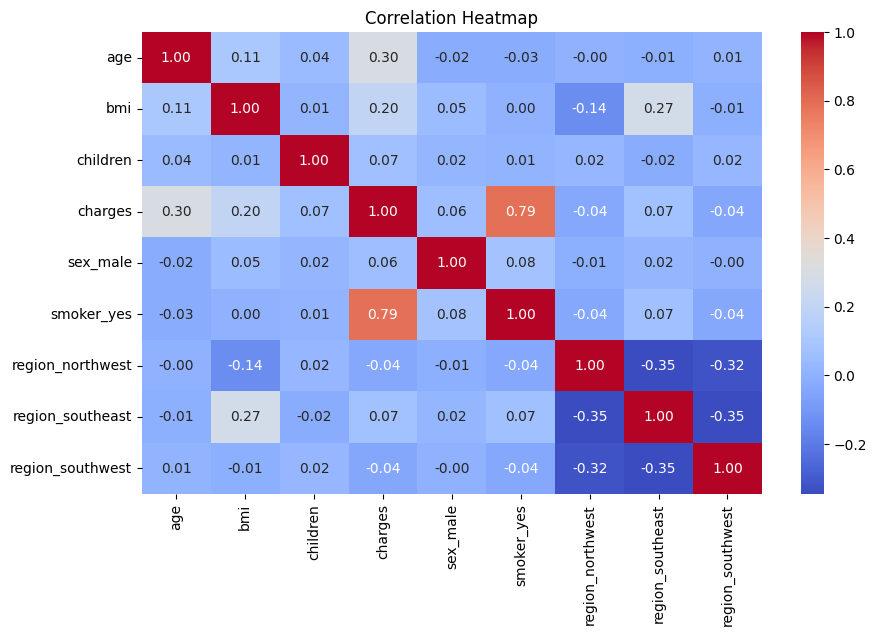

In [84]:
cor_matx = data_final.corr()
plt.figure(figsize=(10,6))
sn.heatmap(cor_matx, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [85]:
# color intensity indicates the strength of the linear relationship between two variables. 
# red (or warm colors): Positive correlation — as one variable increases, the other tends to increase. 
# blue (or cool colors): Negative correlation — as one variable increases, the other tends to decrease. 
# white or light colors: Weak or no correlation.

In [86]:
# define features (X) and set (y) as charges
X = data_final.drop(['charges'], axis=1)
y = data_final['charges']

In [87]:
X.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0


In [88]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

In [89]:
# initialize linear regression model
model_2 = LinearRegression()

In [90]:
# split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [91]:
# transform features to polynomial
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)  # fit and transform training data
X_test_poly = poly.transform(X_test)        # transform test data

In [92]:
# train model
model_2.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [93]:
# make predictions on test data
y_pred = model_2.predict(X_test_poly)

In [94]:
# evaluate model performance
print(f"Improved R2 Score: {model_2.score(X_test_poly, y_test):.4f}")

Improved R2 Score: 0.8666


In [96]:
try:
    
    print("Step 1: Model Fitted Successfully")

    # Step 3: Predict (using the scaled test data)
    y_pred = model_2.predict(X_test)
    print("Step 2: Predictions Generated (y_pred is now defined)")

    # Step 4: Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, color='blue', alpha=0.5, label='Predicted')
    
    # Add the "Perfect Fit" line
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
    
    plt.xlabel('Actual (y_test)')
    plt.ylabel('Predicted (y_pred)')
    plt.title('Actual vs. Predicted Values')
    plt.legend()
    plt.show()
    print("Step 3: Plot Displayed")

except Exception as e:
    print(f"ERROR: {e}")

Step 1: Model Fitted Successfully
ERROR: X has 8 features, but LinearRegression is expecting 44 features as input.


c:\Users\Shmaths\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


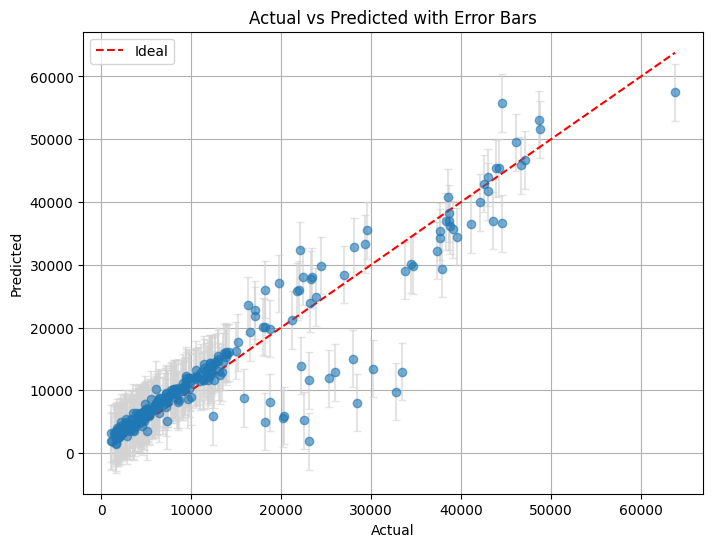

In [97]:

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
error = np.full_like(y_pred, rmse)  # Constant error bar

# Create scatter plot with error bars
plt.figure(figsize=(8, 6))
plt.errorbar(y_test, y_pred, yerr=error, fmt='o', alpha=0.6, ecolor='lightgray', capsize=3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted with Error Bars')
plt.legend()
plt.grid(True)
plt.show()   

In [98]:
# points close to the diagonal line mean accurate predictions. 
# scatter around the line shows prediction errors. 
# even spread of points = good fit; fanning out = increasing error with higher values. 

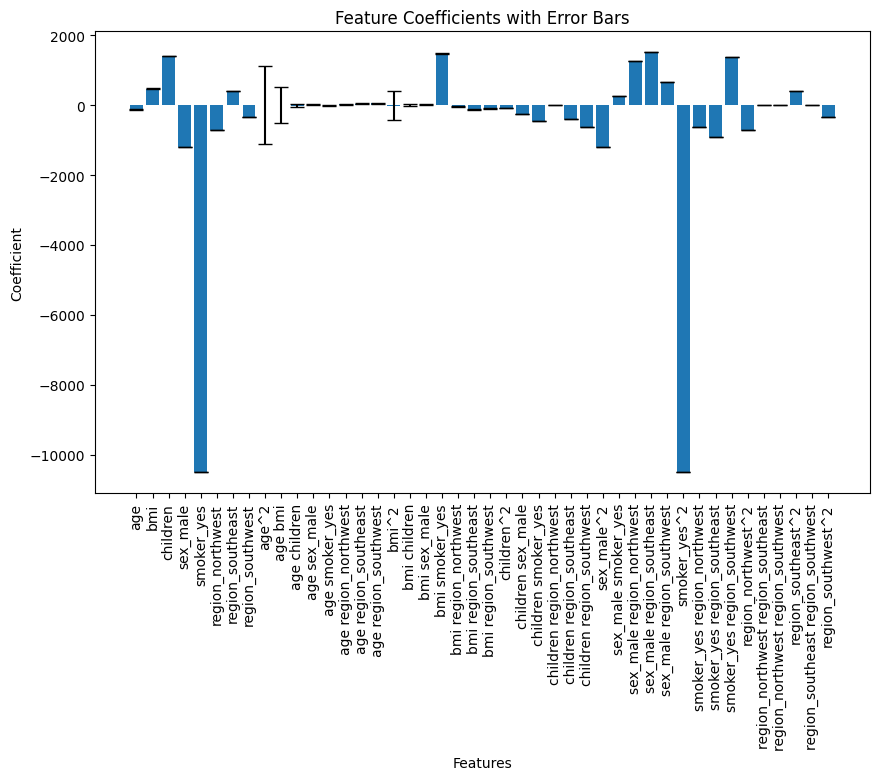

In [99]:
# bar chart with Errors Bars
feature_names = poly.get_feature_names_out(input_features=X_train.columns)
plt.figure(figsize=(10, 6))
plt.bar(feature_names, model_2.coef_, yerr=np.std(X_test_poly, axis=0), capsize=5)
plt.xticks(rotation=90)
plt.xlabel('Features')
plt.ylabel('Coefficient')
plt.title('Feature Coefficients with Error Bars')
plt.show()  

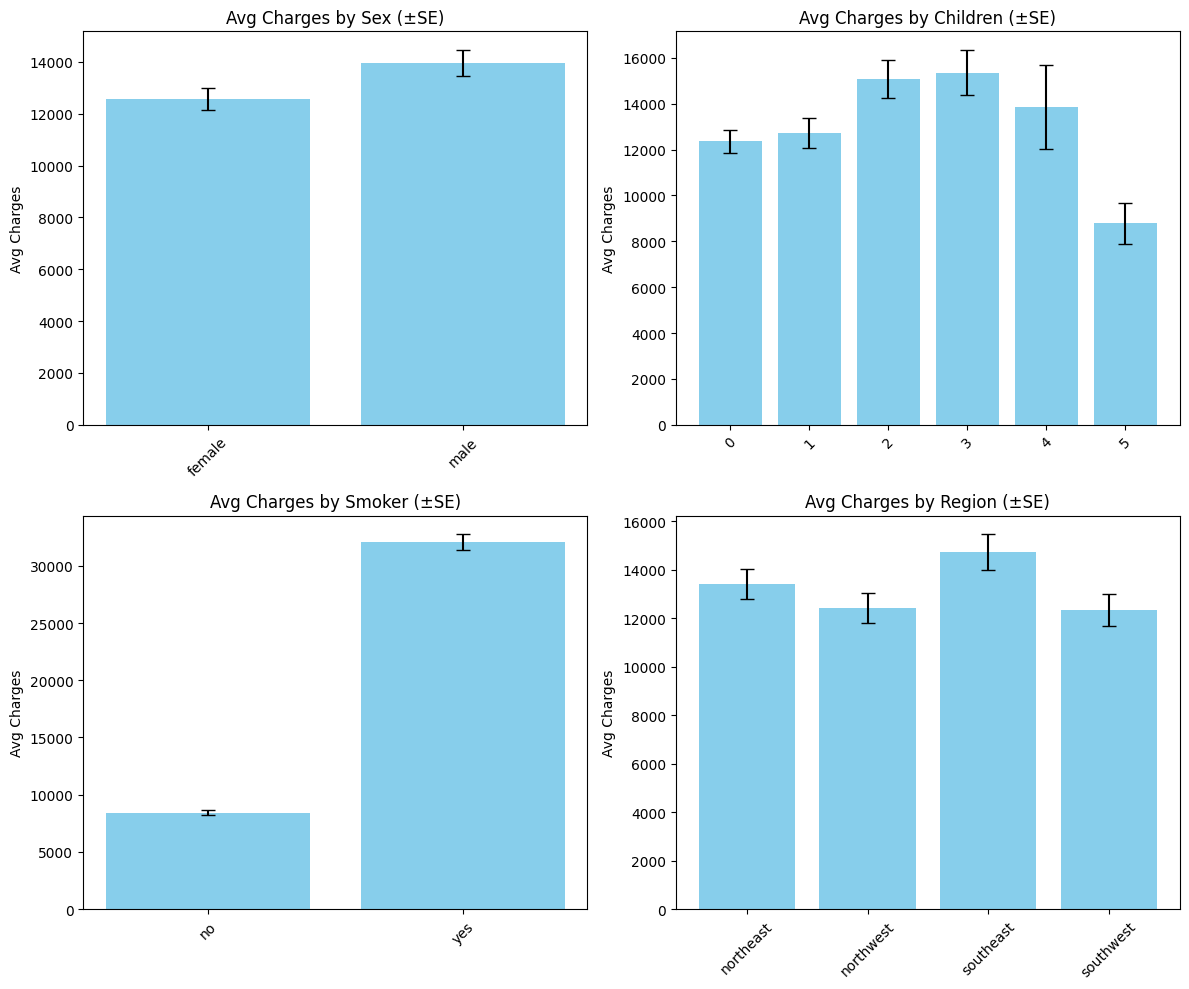

In [100]:
# bar charts with error bars

# define features to plot
features = ['sex', 'children', 'smoker', 'region']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, col in enumerate(features):
    # group by column and calculate mean charges
    grouped = df.groupby(col)['charges'].agg(['mean', 'std', 'count'])
    grouped['se'] = grouped['std'] / np.sqrt(grouped['count'])
    axes[i].bar(grouped.index, grouped['mean'], yerr=grouped['se'], capsize=5, color='skyblue')
    axes[i].set_title(f'Avg Charges by {col.capitalize()} (±SE)')
    axes[i].set_ylabel('Avg Charges')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [102]:
# height of each bar shows the average charges for each group (smokers vs. non-smokers).
# error bars represent uncertainty 
# smaller error bars = more reliable estimate; larger ones = higher variability